***DSC 550 Bakery Model Project***

A problem experienced by many bakeries is knowing how much of a product to purchase or make so that they can sell as many items as possible without having a lot of waste leftover.  Many bakeries only sell the items that they make the day of, so if they overestimate how much that they will sell then a lot of the food will go to waste.  Alternatively, if they underestimate how much they are going to see then they will be missing out on potential salse. It can be difficult to predict how many sales there will be on a given day, but being able to forecast sales based on historical sales information can help give the bakery an idea of how much they may sell on a given day of the week.  In order to do this, I will need historical sales of baked goods, or anything sold by a bakery, and the day of the week that the item was sold.  I will need to create a model to predict future sales based on how the sales trend looks.  The question that I am trying to address is how much of an item should the bakery have readily available each day of the week in order to maximize sales and minimize waste?  The dataset that I am using is from Kaggle and contains transaction details from online purchases from a bakery in Edinburgh from October 2016 to April 2017.

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [186]:
df = pd.read_csv('bakery_sales_revised.csv')
df.head()

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,10/30/2016 9:58,morning,weekend
1,2,Scandinavian,10/30/2016 10:05,morning,weekend
2,2,Scandinavian,10/30/2016 10:05,morning,weekend
3,3,Hot chocolate,10/30/2016 10:07,morning,weekend
4,3,Jam,10/30/2016 10:07,morning,weekend


In [188]:
#convert date_time column to date_time if not already
df['date_time'] = pd.to_datetime(df['date_time'])

In [190]:
#add a column with the day of the week using date_time column
df['day_of_week'] = df['date_time'].dt.day_name()

In [192]:
df.head()

,Transaction,Item,date_time,period_day,weekday_weekend,day_of_week
0,1,Bread,2016-10-30 09:58:00,morning,weekend,Sunday
1,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,Sunday
2,2,Scandinavian,2016-10-30 10:05:00,morning,weekend,Sunday
3,3,Hot chocolate,2016-10-30 10:07:00,morning,weekend,Sunday
4,3,Jam,2016-10-30 10:07:00,morning,weekend,Sunday


In [194]:
#filter df to just bread sales (be sure to add .copy())
df_bread = df[df['Item']=='Bread'].copy()
df_bread.head()

,Transaction,Item,date_time,period_day,weekday_weekend,day_of_week
0,1,Bread,2016-10-30 09:58:00,morning,weekend,Sunday
9,5,Bread,2016-10-30 10:13:00,morning,weekend,Sunday
18,8,Bread,2016-10-30 10:20:00,morning,weekend,Sunday
19,9,Bread,2016-10-30 10:21:00,morning,weekend,Sunday
23,11,Bread,2016-10-30 10:27:00,morning,weekend,Sunday


In [196]:
#put weekdays in order
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
#order day of week column by weeday_order list, and make a categoricall column
df_bread['day_of_week'] = pd.Categorical(df_bread['day_of_week'], categories=weekday_order, ordered=True)
#sort by weekday_order
df_bread = df_bread.sort_values('day_of_week')

In [198]:
bread_sales = df_bread.groupby(['day_of_week'], observed=True).size().reset_index(name='quantity')

In [200]:
bread_sales

,day_of_week,quantity
0,Monday,360
1,Tuesday,350
2,Wednesday,405
3,Thursday,450
4,Friday,527
5,Saturday,760
6,Sunday,473


<BarContainer object of 7 artists>

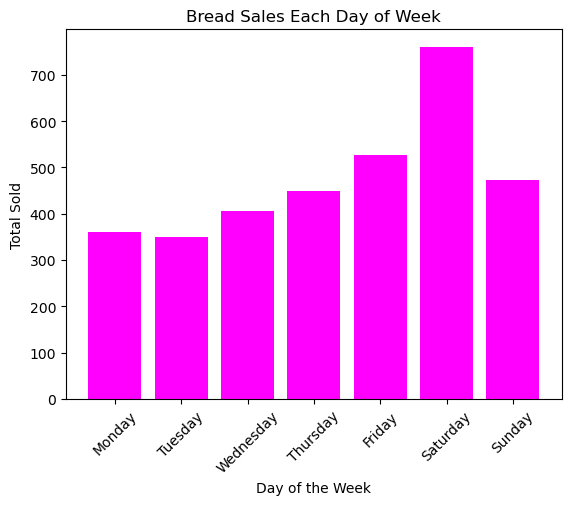

In [202]:
plt.title('Bread Sales Each Day of Week')
plt.ylabel('Total Sold')
plt.xlabel('Day of the Week')
plt.xticks(rotation=45)
plt.bar(bread_sales['day_of_week'], bread_sales['quantity'], color='magenta')

In this graph, we can see that the bakery sells the most bread on saturdays, and the least amount on Tuesdays.  The difference is around 400 items over a few months.

In [205]:
#create a plot of which items are sold the most/least
sales_by_item = df.groupby('Item').size().reset_index(name='quantity_sold')

In [207]:
#get the sales for each item and sort from most to least
sales_by_item = sales_by_item.sort_values(by='quantity_sold', ascending=False)
top_30 = sales_by_item.head(30)

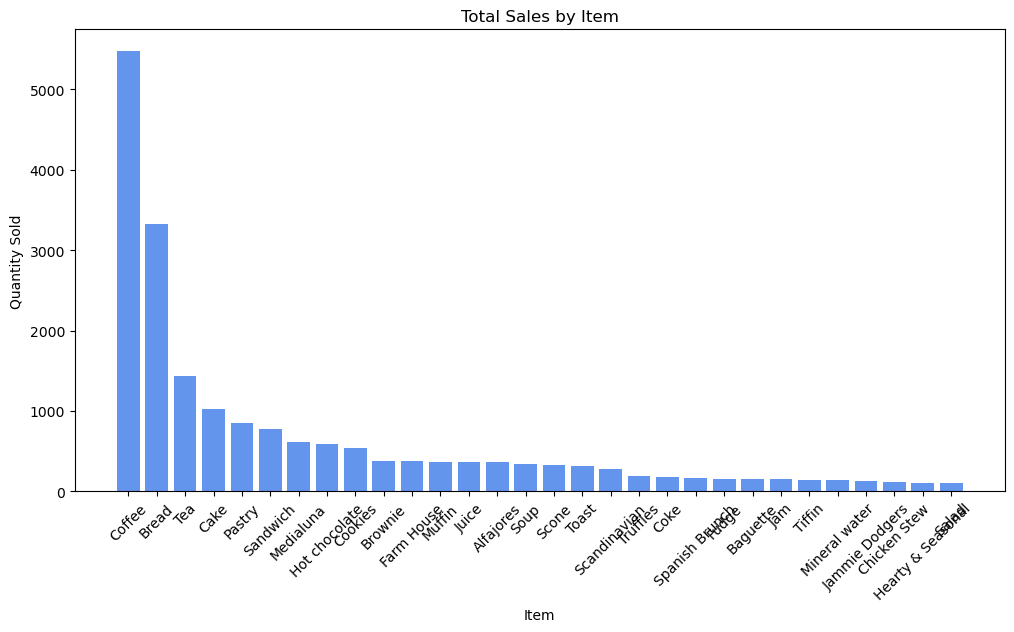

In [209]:
plt.figure(figsize=(12, 6))
plt.bar(top_30['Item'], top_30['quantity_sold'], color='cornflowerblue')
plt.title('Total Sales by Item')
plt.xlabel('Item')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.show()

There were too many items sold to see a graph of them all, but this chart represents the top 30 items sold and the ones that should be focused on the most for sales. Coffee is clearly the most sold item, followed by bread, tea, cake, pastries and sandwiches. These items should be focused on since they are most purchased by consumers.

In [212]:
#create a graph based on sales per each month
#get the month from the date_timem column
df['year_month'] = df['date_time'].dt.to_period('M')

In [214]:
#create a plot of which items are sold the most/least
sales_by_month = df.groupby('year_month').size().reset_index(name='quantity_by_month')
sales_by_month

,year_month,quantity_by_month
0,2016-10,369
1,2016-11,4436
2,2016-12,3339
3,2017-01,3356
4,2017-02,3906
5,2017-03,3944
6,2017-04,1157


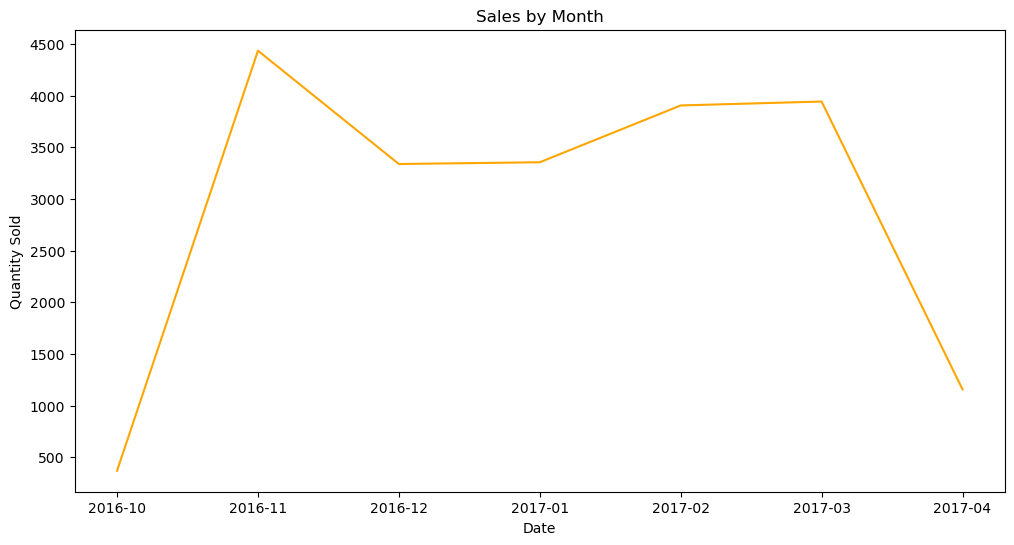

In [216]:
plt.figure(figsize=(12, 6))
plt.plot(sales_by_month['year_month'].astype(str), sales_by_month['quantity_by_month'], color='orange')

plt.title('Sales by Month')
plt.xlabel('Date')
plt.ylabel('Quantity Sold')
plt.show()

There isn't enough data to see how sales may trend over a full year, however we can see the bakery tends to sell around 3500-4000 items each month.  THe numbers are small in 10/2016 and 4/2017 most likely since a full month of data did not get recorded. The most sales did occur in November 2016, around 1000 more items than in December 2016 or January 2017.

In [219]:
#find total sales of every item by week day
#order the df week day names
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=weekday_order, ordered=True)
#sort by weekday_order
df = df.sort_values('day_of_week')

In [221]:
total_sales = df.groupby(['day_of_week'], observed=True).size().reset_index(name='quantity_total')
total_sales

,day_of_week,quantity_total
0,Monday,2324
1,Tuesday,2392
2,Wednesday,2321
3,Thursday,2646
4,Friday,3124
5,Saturday,4605
6,Sunday,3095


<BarContainer object of 7 artists>

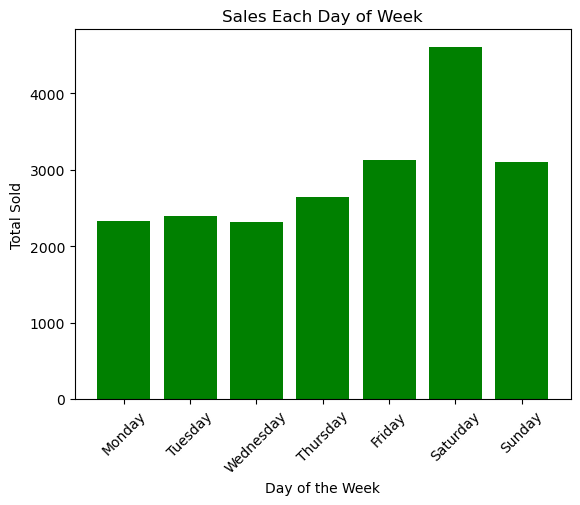

In [223]:
plt.title('Sales Each Day of Week')
plt.ylabel('Total Sold')
plt.xlabel('Day of the Week')
plt.xticks(rotation=45)
plt.bar(total_sales['day_of_week'], total_sales['quantity_total'], color='green')

This graph shows that the most sales occur on Saturdays, with Fridays and Sundays next having a similar number of total sales. Mondays and Wednesdays have the least amount of sales and are similar to Tuesday.  The weekend days and Friday have the highest number of sales.

Conclusion: 
There are a lot of items sold by the bakery, and only a few items have the most sales including coffee, bread and tea, with coffee and bread being the highest by a lot. The most sales occurred on Saturdays, for every single item.  Bread also had the most sales on Saturdays and Fridays and the least on Mondays and Tuesdays. This means that the most bread should be made for Saturdays and much less for Monday and Tuesday. The data was not collected long enough to see a pattern over each month, but the most sales was seen in November and least in December for the full months that were recorded. So far, it seems that the weekends have the most sales, followed by Fridays and Thursdays and the least amount are on Mondays, Tuesdays and Wednesdays. This shows that more bread, coffee and tea need to be available on weekends and Fridays as compared to other days of the week.

----------------------------------------------------------------------------------****MILESTONE 2**** -------------------------------------------------------------------------------

Drop any features that are not useful for your model building and explain why they are not useful.

In [229]:
#dropping the Transaction column in the df
df.drop('Transaction', axis=1, inplace=True)

The transaction column was not useful in that it did not provide any extra information, just counted the total number of transactions.  The other columns can all provide insight that can be helpful for my analysis.

Perform any data extraction/selection steps.

Previously in Milestone 1 I added a day of week column so that I could specifically see which day of the week was connected to each date. This helped to predict how many items should be available each day.

In [234]:
#creating a month and hour column
df['month'] = pd.to_datetime(df['date_time']).dt.month

I decided to add a column for the month number to the dataframe as well to see which months had the best sales. I also added a column that contains just the date without the time also.

In [237]:
df['date'] = df['date_time'].dt.date

Transform features if necessary.

Previously I made sure that the date time column was converted to datetime so that analysis can be done on this column.

In [241]:
#ensure that all values are lowercase in text columns
df['day_of_week'] = df['day_of_week'].str.lower()
df['weekday_weekend'] = df['weekday_weekend'].str.lower()
df['Item'] = df['Item'].str.lower()
df['period_day'] = df['period_day'].str.lower()

In [243]:
df.head()

,Item,date_time,period_day,weekday_weekend,day_of_week,year_month,month,date
13373,sandwich,2017-02-13 15:22:00,afternoon,weekday,monday,2017-02,2,2017-02-13
5318,coffee,2016-12-05 09:28:00,morning,weekday,monday,2016-12,12,2016-12-05
5319,pastry,2016-12-05 09:28:00,morning,weekday,monday,2016-12,12,2016-12-05
5320,alfajores,2016-12-05 09:28:00,morning,weekday,monday,2016-12,12,2016-12-05
5321,coffee,2016-12-05 09:33:00,morning,weekday,monday,2016-12,12,2016-12-05


Deal with missing data (do not just drop rows or columns without justifying this).

In [246]:
#Find any missing data
df.isnull().sum()

Item               0
date_time          0
period_day         0
weekday_weekend    0
day_of_week        0
year_month         0
month              0
date               0
dtype: int64

None of the columns contained any missing data, so I did not drop any rows.

Engineer new useful features.

In order to predict which days of the week have the most sales for specific items, I need to aggregate the info for each item for each day into single rows.

In [251]:
#create a new df with the daily sales aggregated
df_agg = df.groupby(['date', 'Item']).size().reset_index(name='daily_sales')

In [253]:
df_agg.head()

,date,Item,daily_sales
0,2016-10-30,basket,2
1,2016-10-30,bread,29
2,2016-10-30,cake,1
3,2016-10-30,chicken sand,1
4,2016-10-30,coffee,33


In [255]:
#add back the weekday column so that analysis can be done based on items sold during which day of the week rather than the date itself.
df_agg['date'] = pd.to_datetime(df_agg['date'])
df_agg['day_of_week'] = df_agg['date'].dt.day_name()

In [257]:
df_agg.head()

,date,Item,daily_sales,day_of_week
0,2016-10-30,basket,2,Sunday
1,2016-10-30,bread,29,Sunday
2,2016-10-30,cake,1,Sunday
3,2016-10-30,chicken sand,1,Sunday
4,2016-10-30,coffee,33,Sunday


Since I will be using a linear regression model, I need to create dummy variables for the day of week column since it is categorical and also need to create dummy variables for the item column.

In [260]:
df_agg = pd.get_dummies(df_agg, columns=['day_of_week', 'Item'])

In [262]:
df_agg.head()

,date,daily_sales,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,Item_adjustment,...,Item_the bart,Item_the nomad,Item_tiffin,Item_toast,Item_truffles,Item_tshirt,Item_valentine's card,Item_vegan feast,Item_vegan mincepie,Item_victorian sponge
0,2016-10-30,2,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2016-10-30,29,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2016-10-30,1,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2016-10-30,1,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2016-10-30,33,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


--------------------------------------------------------------------------------------**Milestone 3**----------------------------------------------------------------------------------------

For this milestone, I decided to make changes so that I would only be evaluating the top 5 items that the store sells to make one model on. 

In [266]:
#I used this code from milestone 1 to see what the top 5 items are that I will create models for
sales_by_item = sales_by_item.sort_values(by='quantity_sold', ascending=False)
top_5 = sales_by_item.head(5)
top_5

,Item,quantity_sold
23,Coffee,5471
11,Bread,3325
83,Tea,1435
15,Cake,1025
65,Pastry,856


In [268]:
#created a filtered data frame with only the top 5 items
top_items = ['bread', 'coffee', 'tea', 'cake', 'pastry']
df_filtered = df[df['Item'].isin(top_items)]

In [270]:
df_filtered.head()

,Item,date_time,period_day,weekday_weekend,day_of_week,year_month,month,date
5318,coffee,2016-12-05 09:28:00,morning,weekday,monday,2016-12,12,2016-12-05
5319,pastry,2016-12-05 09:28:00,morning,weekday,monday,2016-12,12,2016-12-05
5321,coffee,2016-12-05 09:33:00,morning,weekday,monday,2016-12,12,2016-12-05
5322,coffee,2016-12-05 09:33:00,morning,weekday,monday,2016-12,12,2016-12-05
5325,coffee,2016-12-05 09:33:00,morning,weekday,monday,2016-12,12,2016-12-05


In [272]:
#create another new df that sums up sales with only top 5 items
df_filtered_agg = df_filtered.groupby(['date', 'Item']).size().reset_index(name='daily_sales')

In [274]:
df_filtered_agg.head()

,date,Item,daily_sales
0,2016-10-30,bread,29
1,2016-10-30,cake,1
2,2016-10-30,coffee,33
3,2016-10-30,pastry,6
4,2016-10-30,tea,12


In [276]:
#add back day of the week name
df_filtered_agg['date'] = pd.to_datetime(df_filtered_agg['date'])
df_filtered_agg['day_of_week'] = df_filtered_agg['date'].dt.day_name()

In [278]:
df_filtered_agg.head()

,date,Item,daily_sales,day_of_week
0,2016-10-30,bread,29,Sunday
1,2016-10-30,cake,1,Sunday
2,2016-10-30,coffee,33,Sunday
3,2016-10-30,pastry,6,Sunday
4,2016-10-30,tea,12,Sunday


In [280]:
#drop the date column now since we are analyzing day of the week and items for sale
df_filtered_agg = df_filtered_agg.drop(columns=['date'])

In [282]:
#create dummy variables for the day of the week column and the item column
df_new = pd.get_dummies(df_filtered_agg, columns=['Item','day_of_week'], drop_first=True)

In [291]:
df_new.head()

,daily_sales,Item_cake,Item_coffee,Item_pastry,Item_tea,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,29,False,False,False,False,False,False,True,False,False,False
1,1,True,False,False,False,False,False,True,False,False,False
2,33,False,True,False,False,False,False,True,False,False,False
3,6,False,False,True,False,False,False,True,False,False,False
4,12,False,False,False,True,False,False,True,False,False,False


Using this new information & cleaned up/prepared data set, I will create one model to predict item sales for each day of the week for the top 5 items. The model will try and predict daily_sales.

I decided to use linear regression as my model since I can easily use dummy variables for the categorical columns and I am trying to predict a numerical value. It is also a simple model, which is good to start off with.

In [295]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
#X is everything except daily sales, and y is only daily sales
X = df_new.drop(columns=['daily_sales'])
y = df_new['daily_sales']

In [297]:
#train linear regression model on the training data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [301]:
from sklearn.metrics import mean_squared_error, r2_score

#create new predictions on the testing data using the trained model
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

r2_test = r2_score(y_test, y_pred)
r2_train = r2_score(y_train, y_pred_train)

print("R2 Test: ", r2_test)
print("R2 Train: ", r2_train)

R2 Test:  0.756307131759683
R2 Train:  0.8006887403281221


I decided to compare the R2 values between the predicted test values and the predicted train values so that I can see if my model was overfit.  An over fit model would be one that has a high value for the training data and a significantly lower number for the testing data. In the results above, the R2 scores are similar so I don't believe that the model is overfit.

In [304]:
#calculate RMSE for the training and testing data
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

print('RMSE test: ', rmse_test)
print('RMSE train: ', rmse_train)

RMSE test:  6.227696933253948
RMSE train:  5.772615365631152


Based on the RMSE values for the test and training data, the model seems to do a good job predicting the test values.  For the training data, the model values were off by 5.77 and with the testing data the model was off by 6.23 which is only a difference of 0.46.

Since the model was only able to determine accurate results for 75% of the data with the testing/unseen data, I decided to try a random forest model to see if the results would be more accurate.

In [308]:
from sklearn.ensemble import RandomForestRegressor

In [310]:
#create a random forest model with 100 trees that uses all CPU cores for quicker results
forest_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
forest_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [312]:
#get predicted values for both the testing data and the training data 
y_pred_test_forest = forest_model.predict(X_test)
y_pred_train_forest = forest_model.predict(X_train)

In [314]:
#Get the R2 and RMSE values for the random forest model to see how well model performed on test vs train data
r2_test_forest = r2_score(y_test, y_pred_test_forest)
r2_train_forest = r2_score(y_train, y_pred_train_forest)

rmse_test_forest = np.sqrt(mean_squared_error(y_test, y_pred_test_forest))
rmse_train_forest = np.sqrt(mean_squared_error(y_train, y_pred_train_forest))

print("R2 Test Forest: ", r2_test_forest)
print("R2 Train Forest: ", r2_train_forest)
print("RMSE Test Forest: ", rmse_test_forest)
print("RMSE Train Forest: ", rmse_train_forest)

R2 Test Forest:  0.7679395272864801
R2 Train Forest:  0.8432427328785892
RMSE Test Forest:  6.077243618383087
RMSE Train Forest:  5.119417465974668


The random forest model has a higher R2 value for the training data than the linear regression model, meaning it was able to predict more values correctly with this type of model while training.  The testing data did not go up as much as the training data, which could be a risk for overfitting, however the R2 value for the test data still did go up a small amount from 75.6% to 76.7% which means the random forest model performed slightly better.  The RMSE values for both the test and training data went down as compared to linear regression, which means that the predicted values were much closer to the actual values in the random forest model.

Overall the random forest model was a better predictor in this situation, but only by a very little amount.